# Наивный байесовский классификатор

**Наивный байесовский классификатор** — это простой, но мощный вероятностный алгоритм для задач классификации, основанный на теореме Байеса и предположении о независимости признаков (отсюда "наивный"). Это предположение часто не выполняется в реальных задачах, но несмотря на это, алгоритм часто показывает хорошие результаты.

НБК используется в таких задачах, как: 
* классификация текста, например, классификация электронных писем как спам или не спам; 
* анализ комментариев - определение тона (положительный, отрицательный, нейтральный); 
* системы рекомендаций - может быть использован для рекомендаций на основе пользовательских предпочтений.

## Преимущества и недостатки наивного байесовского классификатора

**Преимущества:**

- простота в реализации и интерпретации;

- практически не требуется настройка параметров;

- высокая скорость работы и точность прогнозов во многих ситуациях;

- имеет относительно хорошую устойчивость к шуму и выбросам, поскольку основан на вероятностных распределениях и наивном предположении о независимости признаков.

**Недостатки:**

- в случае нарушения предположения о независимости признаков, точность прогнозов может значительно снизиться;

- может отдавать предпочтение к классам с бОльшим количеством образцов в случае несбалансированных данных.

## Как он устроен?

### Вероятностная модель НБК

Это будет условная модель $p(c|x_1,...,x_n)$ над зависимой переменной класса c, зависимая от нескольких переменных $(x_1,...,x_n)$, n — число признаков.

$$ P(c|x_1,...,x_n) = \frac{P(x_1,...,x_n|c)P(c)}{P(x_1,...,x_n)}$$

Где: 
* $P(c|x_1,...,x_n)$ - искомая апостериорная вероятность класса $с$ при таких входных данных,
* $P(x_1,...,x_n|c)$ — смотрятся только те строки из таблицы, где выходной класс равен $c$, и среди них считается вероятность каждого вида входных признаков,
* $P(c)$ — априорная вероятность класса $с$ (рассчитывается из набора данных), 
* $P(x_1,...,x_n)$ — априорная вероятность того, что будут такие значения входных признаков.

Поскольку мы делаем допущение, что признаки независимы, тогда вычисление вероятности упрощается и получается следующая формула:

$$ P(c|x_1,...,x_n) = \frac{P(c) \cdot \prod_{i = 1}^{n} P(x_i|c) }{\prod_{i = 1}^{n} P(x_i)}$$

### Построение модели НБК

**Сделаем дополнительное допущение о нормальности распределения непрерывных признаков.**

**Основные формулы гауссовской модели:**

* формула для оценки меток классов (основная формула модели):

$$\hat C_k = \underset{C_k}{\arg\max}\ \underbrace{\left(\log P(y = C_k)+  \sum_{i=1}^m\log P(x_i|y = C_k)\right)}_{\approx\log P(y = C_k)+ \log P(x_1,\ldots,x_m|y=C_k)};$$

* формула для априорных вероятностей 

$$P(y = C_k) = \dfrac{\text{количество объектов класса } k}{\text{количество всех объектов}} = P(c);$$

* формула для гауссовского распределения признаков 

$$P(x_i|y = C_k) = \dfrac{1}{\sigma_{C_k}\sqrt{2\pi}}\exp \left(-\dfrac{(x_i - \mu_{C_k})^2}{2 \sigma_{C_k}^2}\right), $$

где по методу максимального правдоподобия,

$$\mu_{C_k} = \dfrac 1 m\sum_{i=1}^m x_i,\ \sigma_{C_k}^2 = \dfrac 1 m\sum_{i=1}^m (x_i - \mu_{C_k})^2.$$

### Вопрос: Почему в формуле для оценки меток классов пропал знаменатель?

### Вопрос: Почему в формуле для оценки меток классов используется логарифм?

### Реализация модели

В библиотеке scikit-learn есть готовая реализация гауссовского наивного баейса.

Рассмотрим его работу на примере набора данных Ирисы. 

В наборе 150 объектов (цветков), равномерно распределённых по трём классам (по 50 экземпляров каждого вида). Каждый объект описывается четырьмя числовыми признаками, которые измеряются в сантиметрах:

    * Длина чашелистика (sepal length)

    * Ширина чашелистика (sepal width)

    * Длина лепестка (petal length)

    * Ширина лепестка (petal width)

Целевая переменная (класс, который мы предсказываем):

    0 — Iris setosa

    1 — Iris versicolor

    2 — Iris virginica

In [90]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.colors import ListedColormap
import seaborn as sns
from sklearn.datasets import load_iris, make_blobs, make_classification, make_moons
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.naive_bayes import GaussianNB
import pandas as pd

In [91]:
X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=0)

gnb = GaussianNB()
y_pred = gnb.fit(X_train, y_train).predict(X_test)

print("Number of mislabeled points out of a total %d points : %d"
      % (X_test.shape[0], (y_test != y_pred).sum()))

Number of mislabeled points out of a total 75 points : 4


Попробуем реализовать байес самостоятельно.

**Задание: реализуйте класс гауссовского НБК.**

In [ ]:
import numpy as np 

class NaiveBayesClassifier():

    # Правдоподобие признаков
    def _compute_likelihood(self, x, mean, var):
        """Вычисление правдоподобия признаков"""
        return np.exp(-0.5 * np.power((x - mean) / np.sqrt(var), 2)) / (np.sqrt(2 * np.pi) * np.sqrt(var)) # TODO: Здесь должна быть формула для гауссовского распределения признаков 


    def _compute_log_posterior(self, x):
        """Вычисление логарифма апостериорной вероятности"""
        log_posteriors = []

        # Вычисление апостериорных вероятностей
        for i, c in enumerate(self.classes):
            log_p_xm_y = np.log(self.priors[i]) + np.sum(np.log(self._compute_likelihood(x, self.mean[i], self.var[i]))) # TODO: Здесь должна быть основная формула модели
            log_posteriors.append(log_p_xm_y) 

        # Вычисление оценки класса как argmax
        return self.classes[np.argmax(log_posteriors)] # TODO: Выведите класс, у которого максимальная вероятность


    def fit(self, X, y):
        """Обучение модели"""
        n_samples, n_features = X.shape
        self.classes = np.unique(y)
        n_classes = len(self.classes) # Количество классов C_1, ..., C_k

        self.mean = np.zeros((n_classes, n_features))
        self.var = np.zeros((n_classes, n_features))
        self.priors = np.zeros((n_classes))

        for i, C in enumerate(self.classes):
            X_C = X[y == C] # Выбираем из выборки все объекты, для которых класс равен C
            self.mean[i] = X_C.mean(axis=0) # TODO: Заметьте, что среднее и дисперсия берутся по признакам, а не по объектам
            self.var[i] = X_C.var(axis=0) # TODO
            self.priors[i] = len(X_C) / n_samples # TODO: Априорные вероятности
        
        return self


    def predict(self, X):
        """Предсказания модели"""
        return np.array([self._compute_log_posterior(x) for x in X]) # TODO: Прогнозируем метку класса как апостериорный максимум с помощью метода _compute_log_posterior по каждому признаку. Возвращаемый тип np.array()

In [95]:
nb = NaiveBayesClassifier()
y_pred = nb.fit(X_train, y_train).predict(X_test)

print("Number of mislabeled points out of a total %d points : %d"
      % (X_test.shape[0], (y_test != y_pred).sum()))

print((y_pred == gnb.predict(X_test)).sum() == X_test.shape[0])

Number of mislabeled points out of a total 75 points : 4
True


### Визуальный пример работы алгоритма

In [96]:
# Функция для отображения границ решения
def plot_decision_boundaries(X, y, model, ax=None, title="Decision Boundaries"):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))

    # Определяем границы графика с небольшим запасом
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    # Создаем сетку точек для построения границы
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))

    # Предсказываем класс для каждой точки сетки
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Определяем цветовую схему
    colors = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])

    # Отображаем границы решения
    ax.contourf(xx, yy, Z, alpha=0.4, cmap=colors)

    # Отображаем обучающие точки
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, s=80, edgecolor='k', cmap=colors)

    # Добавляем легенду
    legend1 = ax.legend(*scatter.legend_elements(), title="Классы")
    ax.add_artist(legend1)

    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    ax.set_title(title)
    ax.set_xlabel('Признак 1')
    ax.set_ylabel('Признак 2')

    return ax

In [97]:
# Выбираем только два признака (например, 0 и 1)
X_two_features = X[:, [0, 1]]  # Длина чашелистика и ширина чашелистика

# Разделение данных
X_train, X_test, y_train, y_test = train_test_split(
    X_two_features, y, test_size=0.3, random_state=0
)

# Обучение модели
gnb = GaussianNB()
y_pred = gnb.fit(X_train, y_train).predict(X_test)

print("Number of mislabeled points out of a total %d points : %d"
      % (X_test.shape[0], (y_test != y_pred).sum()))

Number of mislabeled points out of a total 45 points : 9


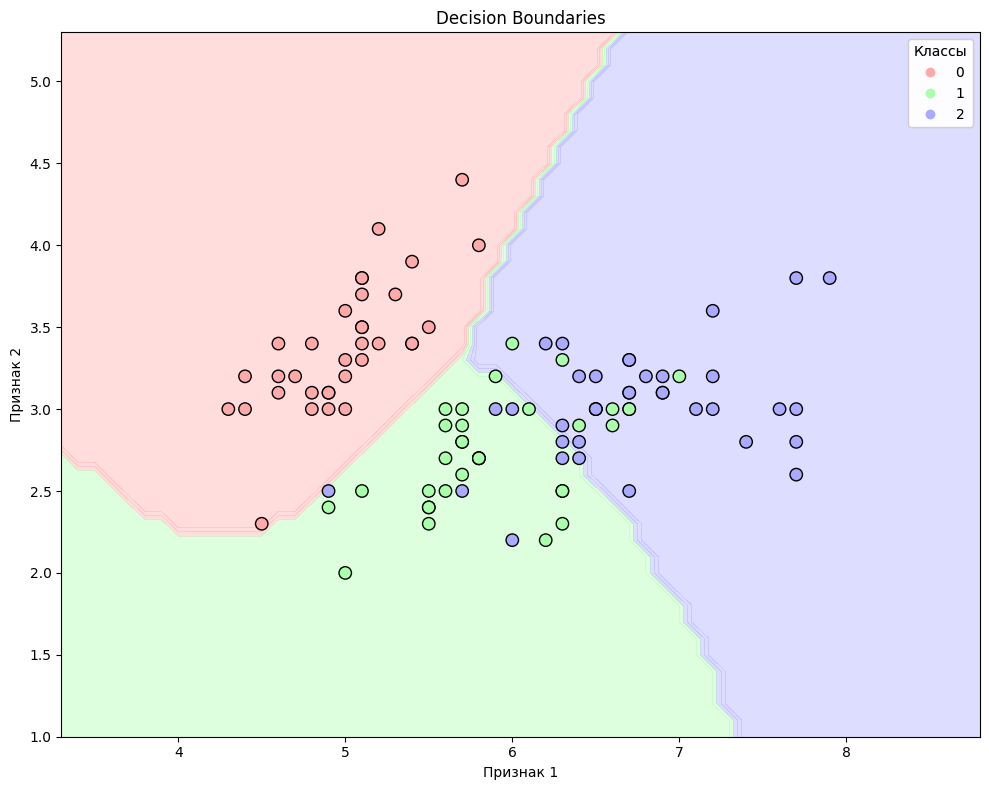

In [98]:
plot_decision_boundaries(X_train, y_train, gnb)

plt.tight_layout()
plt.show()

**Задание: Обучите модель и отрисуйте графики для следующих трех датасетов**

In [59]:
def generate_complex_data(n_samples=100):
    
    # Класс A: Кластер в форме кольца
    theta_A = 2 * np.pi * np.random.rand(n_samples)
    r_A = 3 + 0.5 * np.random.randn(n_samples)
    x_A = r_A * np.cos(theta_A)
    y_A = r_A * np.sin(theta_A)
    data_A = np.column_stack((x_A, y_A))
    labels_A = np.zeros(n_samples)

    # Класс B: Кластер в центре
    data_B = np.random.multivariate_normal([0, 0], [[1, 0], [0, 1]], n_samples)
    labels_B = np.ones(n_samples)

    # Класс C: Два вытянутых кластера
    data_C1 = np.random.multivariate_normal([5, 5], [[1, 0.5], [0.5, 1]], int(n_samples/2))
    data_C2 = np.random.multivariate_normal([-5, -5], [[1, -0.5], [-0.5, 1]], int(n_samples/2))
    data_C = np.vstack((data_C1, data_C2))
    labels_C = np.full(n_samples, 2)

    X = np.vstack((data_A, data_B, data_C))
    y = np.hstack((labels_A, labels_B, labels_C))

    return X, y

In [ ]:
# Датасет 1: простые блобы
X_blobs, y_blobs = make_blobs(n_samples=200, centers=3, cluster_std=1.8, random_state=0)

# Датасет 2: более сложный, линейно неразделимый
X_moons, y_moons = make_moons(n_samples=200, noise=0.1, random_state=0)

# Датасет 3: сложные линейно неразделимые данные
X_complex, y_complex = generate_complex_data(n_samples=200)

In [ ]:
# Разделите данные на обучающую и тестовую выборки в соотношении 7:3
...

Дополнительно рассмотреть случай, когда элементов класса С сильно больше, чем остальных в 3 датасете - демонстрация того, почему НБК не всегда хорошо работает

## Мультиномиальный НБК

Предыдущая формула подходила для непрерывных признаков, когда набор данных распределен нормально. Но текстовые данные не являются непрерывными - в них нет нецелочисленных значений, и мы не можем до бесконечности придумывать слова между двумя другими. 

Поэтому, чтобы на словах, новых для данного класса(тематики), алгоритм не выдавал постоянно 0, формула вероятности набора признака при текущем классе меняет немного свой вид. Такое решение называется аддитивным сглаживанием (сглаживанием Лапласа). Идея заключается в том что мы притворяемся как будто видели каждое слово на один раз больше, то есть прибавляем единицу к частоте каждого слова.

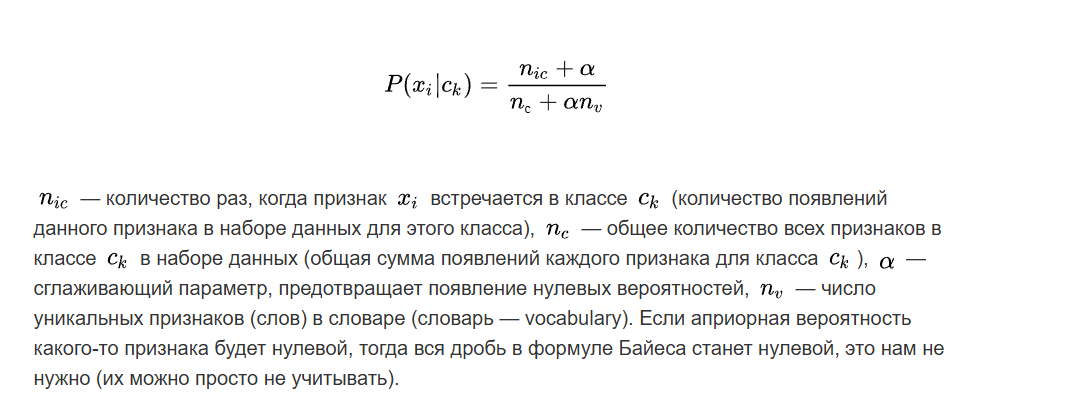

Логически данный подход смещает оценку вероятностей в сторону менее вероятных исходов. Таким образом, слова которые мы не видели на этапе обучения модели получают пусть маленькую, но все же не нулевую вероятность. Вот как это выглядит на практике. Допустим на этапе обучения мы видели три имени собственных указанное количество раз.

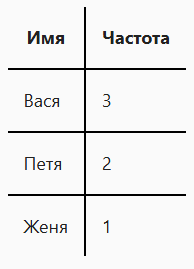

И тут на этапе классификации у нас появляется имя Иннокентий, которое мы не видели на этапе обучения. Тогда оригинальная и смещённая по Лапласу оценка вероятностей будет выглядеть следующим образом.

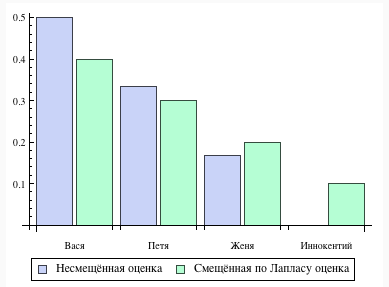

Из графика видно что смещённая оценка никогда не бывает нулевой, что защищает нас от проблемы неизвестных слов.

### Построение модели

Для реализации Байесовского классификатора нам необходима обучающая выборка в которой проставлены соответствия между текстовыми документами и их классами. Затем нам необходимо собрать следующую статистику из выборки, которая будет использоваться на этапе классификации:

* относительные частоты классов в корпусе документов. То есть, как часто встречаются документы того или иного класса;
* суммарное количество слов в документах каждого класса;
* относительные частоты слов в пределах каждого класса;
* размер словаря выборки. Количество уникальных слов в выборке.

Совокупность этой информации мы будем называть моделью классификатора. Затем на этапе классификации необходимо для каждого класса рассчитать значение следующего выражения и выбрать класс с максимальным значением.

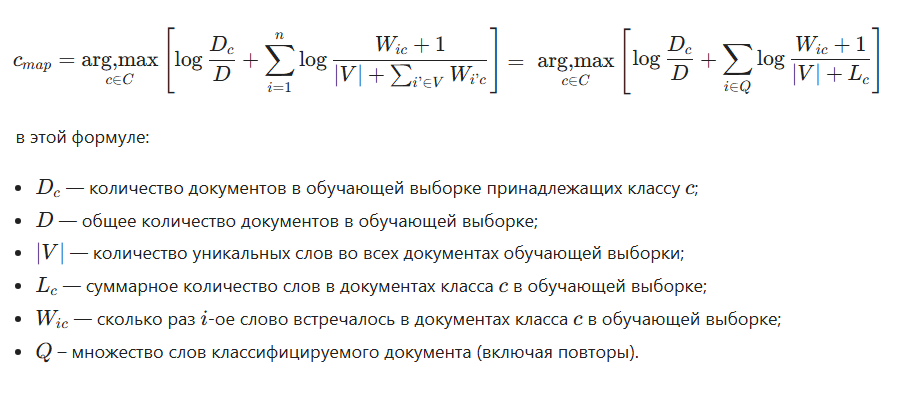

## Применение к тексту

Набор данных, который мы будем использовать, будет состоять из текстовых данных, сгруппированных по четырём категориям: Технологии, Спорт, Политика и Развлечения. Каждая запись содержит короткое предложение или утверждение, связанное с определённой темой, с указанием категории, к которой оно относится. Всего 85 записей. Вы можете загрузить набор данных [здесь](https://media.geeksforgeeks.org/wp-content/uploads/20250303132330481308/synthetic_text_data.csv).

Стандартная задача классификации.

Допустим вы очистили и подготовили данные, провели токенизацию. Поскольку для НБК важна только частота, то для векторизации неоходимо и достаточно взять CountVectorizer - мешок слов.

Пример:
Словарь: ["я", "люблю", "машинное", "обучение", "ненавижу"]
Предложение: "Я люблю машинное обучение" →
Вектор: [1, 1, 1, 1, 0] 

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix

In [61]:
# Читаем данные
data = pd.read_csv('synthetic_text_data.csv')
X = data['text']
y = data['label']

In [62]:
data.head()

,text,label
0,Artificial intelligence is advancing in health...,Technology
1,Football fans are excited about the upcoming W...,Sports
2,New policies regarding climate change have spa...,Politics
3,The latest blockbuster movie has shattered box...,Entertainment
4,Quantum computing promises to revolutionize in...,Technology


In [84]:
# Делим на обучающую и тестовую выборки, поскольку это алгоритм, то ему не нужна валидационная выборка
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

Поскольку алгоритм работает с числами, то нам необходимо векторизовать наши записи. Для этого нам пригодится CountVectorizer.

Как работает CountVectorizer?

1. Токенизация: Текст разбивается на отдельные слова (или n-граммы).

2. Построение словаря: Уникальные слова из всех документов образуют векторное пространство (каждое слово — это признак).

3. Векторизация: Каждый документ представляется вектором, где:

    * Индекс = позиция слова в словаре.

    * Значение = частота слова в документе (count).

In [ ]:
# Токенизация и векторизация с помощью CountVectorizer
vectorizer = CountVectorizer()
X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)

In [86]:
# Инициализация и тренировка модели, вы можете задать параметр alpha (по умолчанию равен 1)
model = MultinomialNB()
model.fit(X_train_vectorized, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [87]:
# Само предсказание
y_pred = model.predict(X_test_vectorized)

Accuracy (Точность): 84.61538461538461%


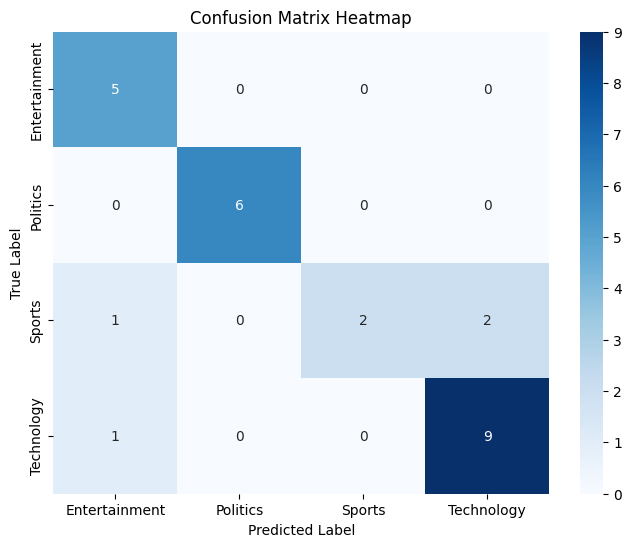

In [88]:
# Поскольку у нас задача классификации, то для анализа качества работы модели можно использовать метрику accuracy
accuracy = accuracy_score(y_test, y_pred)

# confusion_matrix(): Создает матрицу ошибок, чтобы наглядно показать, насколько хорошо модель классифицирует каждую категорию.
conf_matrix = confusion_matrix(y_test, y_pred)

print(f'Accuracy (Точность): {accuracy *100}%')

class_labels = np.unique(y_test)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


Глядя на тепловую карту матрицы ошибок, мы видим, что модель сделала правильные прогнозы для развлечений(5), политики(6), спорта (2) и технологий (9). На тепловой карте эти значения показаны более тёмными цветами, обозначающими правильные прогнозы. Однако были и ошибочные классификации.

In [ ]:
# Предсказание на новых данных
user_input = ("I love machine learning")

user_input_vectorized = vectorizer.transform([user_input])
predicted_label = model.predict(user_input_vectorized)
print(f"The input text belongs to the '{predicted_label[0]}' category.")

The input text belongs to the 'Technology' category.


**Задание:**
**самостоятельно реализуйте класс Мультиномиального НБК**


In [ ]:
import numpy as np # при отправке не забудьте добавить все необходимые библиотеки

class MultinomialNaiveBayesClassifier():
    
    def __init__(self, alpha=1.0):
        """
        alpha: параметр сглаживания Лапласа (по умолчанию 1.0)
        """
        self.alpha = alpha
        self.classes = None # множество C возможных классов(категорий) c в y 
        self.feature_probs = None # P(word|class), правдоподобие (см. логарифмы под суммой)
        self.class_probs = None # D_c / D, априорная вероятность класса
        
    def _compute_log_posterior(self, x):
        """Вычисление логарифма апостериорной вероятности"""
        log_posteriors = []
        
        for i, c in enumerate(self.classes):
            # Логарифм априорной вероятности класса -  то, что мы знали ДО наблюдения данных
            log_prior = ... # TODO: Возьмите нужный логарифм

            # Логарифм правдоподобия - вероятность данных ПРИ условии параметров x (зависит от х!)
            log_likelihood = ... # TODO: Возьмите нужный логарифм и сумму 
            
            # Апостериорная вероятность - то, что мы знаем ПОСЛЕ наблюдения данных
            log_posterior = ... # TODO: Здесь должна быть основная формула модели
            log_posteriors.append(log_posterior)
            
        return self.classes[np.argmax(log_posteriors)]
    
    def fit(self, X, y):
        """
        Обучение мультиномиального наивного байесовского классификатора
        
        X: матрица признаков (n_samples, n_features), может быть разреженной
           где значения представляют частоты слов/токенов
        y: вектор меток классов (должен быть numpy array или список)
        """
        # Преобразуем y в numpy array
        y = np.asarray(y)
        
        n_samples, n_features = X.shape # D, n_v = |V|
        self.classes = np.unique(y)
        n_classes = len(self.classes)
        
        # Инициализация массивов
        self.feature_probs = np.zeros((n_classes, n_features))
        self.class_probs = np.zeros(n_classes)
        
        for i, c in enumerate(self.classes):
            X_c = X[y == c] # Выбираем из выборки все объекты, для которых класс равен c
            
            # Априорная вероятность класса
            self.class_probs[i] = ... # TODO: D_c / D
            
            # Сумма частот всех слов в классе
            total_word_count = ... # TODO: L_c = n_c
            
            # Сумма частот каждого признака в классе
            feature_counts = ... # TODO: n_ic = W_ic
            
            # Применение сглаживания Лапласа и вычисление вероятностей
            self.feature_probs[i] = ... # TODO: P(word|class) = (count(word, class) + alpha) / (total_words_in_class + alpha * n_features)
        
        return self
    
    def predict(self, X):
        """Предсказание классов для новых данных"""
        return ... # TODO: Прогнозируем метку класса как апостериорный максимум с помощью метода _compute_log_posterior по каждому признаку. Возвращаемый тип np.array()
    